# Data, NLP Preprocessing & Classic ML Baseline

**Fake News Detection (EE7260)**

This notebook covers:

1. **NLP preprocessing** — cleaning, tokenisation, stop-word removal, lemmatisation, and TF-IDF features.
2. **Classic ML baseline** — TF-IDF + Logistic Regression / Passive-Aggressive / Naive Bayes. This baseline is later compared against the DistilBERT and LLM approaches.

**Dataset:** `GonzaloA/fake_news` (Hugging Face, auto-downloads). Binary labels: `0 = FAKE`, `1 = REAL`.

Outputs are saved to `../results/` so the comparison notebook and the demo app can reuse them.

In [1]:
import os, re, json, warnings
from pathlib import Path
from time import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Download NLTK data (one-time)
import nltk
for pkg in ['stopwords', 'wordnet', 'omw-1.4', 'punkt', 'punkt_tab']:
    nltk.download(pkg, quiet=True)

RESULTS_DIR = Path('..') / 'results'
RESULTS_DIR.mkdir(exist_ok=True)
(RESULTS_DIR / 'models').mkdir(exist_ok=True)

RANDOM_STATE = 42
print('Setup complete. Results ->', RESULTS_DIR.resolve())

Matplotlib is building the font cache; this may take a moment.


Setup complete. Results -> D:\AI 103\FakeNewsDetection\results


## 1. Load the dataset

`GonzaloA/fake_news` ships with `train` / `validation` / `test` splits and the columns `title`, `text`, `label`. It downloads automatically the first time (cached afterwards).

In [2]:
from datasets import load_dataset

ds = load_dataset('GonzaloA/fake_news')
print(ds)
print('\nFeatures:', ds['train'].features)

README.md:   0%|          | 0.00/6.73k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/38.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/13.0M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/13.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/24353 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8117 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8117 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'title', 'text', 'label'],
        num_rows: 24353
    })
    validation: Dataset({
        features: ['Unnamed: 0', 'title', 'text', 'label'],
        num_rows: 8117
    })
    test: Dataset({
        features: ['Unnamed: 0', 'title', 'text', 'label'],
        num_rows: 8117
    })
})

Features: {'Unnamed: 0': Value('int64'), 'title': Value('string'), 'text': Value('string'), 'label': Value('int64')}


In [3]:
train_df = ds['train'].to_pandas()
test_df = ds['test'].to_pandas()

# Combine title + body into a single text field
for df in (train_df, test_df):
    df['content'] = (df['title'].fillna('') + '. ' + df['text'].fillna('')).str.strip()

LABEL_NAMES = {0: 'FAKE', 1: 'REAL'}

print('Train rows:', len(train_df), '| Test rows:', len(test_df))
print('\nLabel counts (train):')
print(train_df['label'].value_counts())

print('\nOne example per label:')
for lab in sorted(train_df['label'].unique()):
    row = train_df[train_df['label'] == lab].iloc[0]
    print(f"label {lab} -> {LABEL_NAMES.get(lab)} | {str(row['title'])[:90]}")

Train rows: 24353 | Test rows: 8117

Label counts (train):
label
1    13195
0    11158
Name: count, dtype: int64

One example per label:
label 0 -> FAKE |  ‘Maury’ Show Official Facebook Posts F*CKED UP Caption On Guest That Looks Like Ted Cruz 


label 1 -> REAL | Russia warns Iraq, Kurds not to destabilize Middle East after Kurdish vote


## 2. Exploratory data analysis

Check the class balance and the distribution of article lengths.

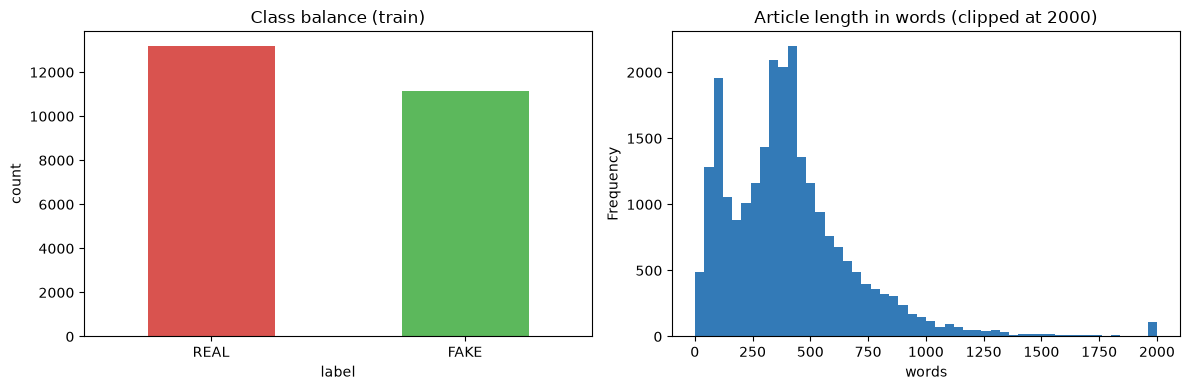

count    24353.0
mean       418.3
std        334.8
min          2.0
25%        220.0
50%        377.0
75%        527.0
max       7221.0
Name: word_count, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df['label'].map(LABEL_NAMES).value_counts().plot(
    kind='bar', ax=axes[0], color=['#d9534f', '#5cb85c'])
axes[0].set_title('Class balance (train)')
axes[0].set_ylabel('count')
axes[0].tick_params(axis='x', rotation=0)

train_df['word_count'] = train_df['content'].str.split().str.len()
train_df['word_count'].clip(upper=2000).plot(
    kind='hist', bins=50, ax=axes[1], color='#337ab7')
axes[1].set_title('Article length in words (clipped at 2000)')
axes[1].set_xlabel('words')

plt.tight_layout()
plt.show()

print(train_df['word_count'].describe().round(1))

## 3. NLP preprocessing

Standard text-cleaning pipeline: lowercase, remove URLs and non-alphabetic characters, drop stop-words and very short tokens, then lemmatise each remaining word.

In [5]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOP = set(stopwords.words('english'))
LEMM = WordNetLemmatizer()
URL_RE = re.compile(r'http\S+|www\.\S+')
NON_ALPHA_RE = re.compile(r'[^a-z\s]')

def clean_text(text):
    text = str(text).lower()
    text = URL_RE.sub(' ', text)
    text = NON_ALPHA_RE.sub(' ', text)
    tokens = [LEMM.lemmatize(w) for w in text.split() if w not in STOP and len(w) > 2]
    return ' '.join(tokens)

# Demo on the first article
print('RAW :', train_df['content'].iloc[0][:200])
print()
print('CLEAN:', clean_text(train_df['content'].iloc[0])[:200])

RAW : ‘Maury’ Show Official Facebook Posts F*CKED UP Caption On Guest That Looks Like Ted Cruz (IMAGE). Maury is perhaps one of the trashiest shows on television today. It s right in line with the likes of 



CLEAN: maury show official facebook post cked caption guest look like ted cruz image maury perhaps one trashiest show television today right line like gutter trash jerry springer fact show still air shit air


In [6]:
t0 = time()
train_df['clean'] = train_df['content'].map(clean_text)
test_df['clean'] = test_df['content'].map(clean_text)
print('Preprocessed', len(train_df) + len(test_df), 'articles in', round(time() - t0, 1), 's')
train_df[['content', 'clean']].head(2)

Preprocessed 32470 articles in 54.5 s


,content,clean
0,‘Maury’ Show Official Facebook Posts F*CKED UP...,maury show official facebook post cked caption...
1,Trump’s Favorite News Channel Tries To Soothe ...,trump favorite news channel try soothe battere...


## 4. TF-IDF features

Convert the cleaned text into TF-IDF vectors (unigrams + bigrams). These vectors are the input features for the baseline classifiers.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=5)
X_train = vectorizer.fit_transform(train_df['clean'])
X_test = vectorizer.transform(test_df['clean'])
y_train = train_df['label'].values
y_test = test_df['label'].values

print('TF-IDF train matrix:', X_train.shape)
print('TF-IDF test matrix :', X_test.shape)

TF-IDF train matrix: (24353, 20000)
TF-IDF test matrix : (8117, 20000)


## 5. Baseline classifiers

Train three classic models on the TF-IDF features and pick the best one as the baseline.

In [8]:
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, C=2.0),
    'PassiveAggressive': PassiveAggressiveClassifier(max_iter=1000, random_state=RANDOM_STATE),
    'MultinomialNB': MultinomialNB(),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, 'trained')

LogisticRegression trained


PassiveAggressive trained
MultinomialNB trained


## 6. Evaluation

Compare the models on the test set using accuracy, precision, recall and F1, then show the confusion matrix and full classification report for the best one.

In [9]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

results = {}
for name, model in models.items():
    pred = model.predict(X_test)
    results[name] = {
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
    }

results_df = pd.DataFrame(results).T.sort_values('f1', ascending=False)
results_df.round(4)

,accuracy,precision,recall,f1
PassiveAggressive,0.9762,0.9767,0.9788,0.9778
LogisticRegression,0.9713,0.9754,0.9707,0.9731
MultinomialNB,0.9390,0.9526,0.9322,0.9423


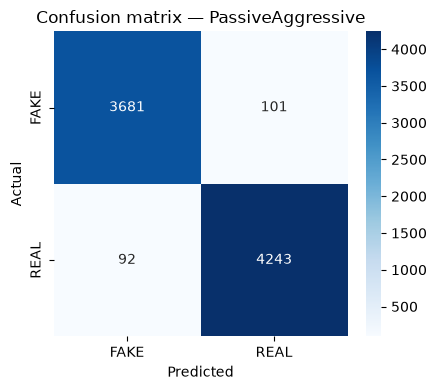

              precision    recall  f1-score   support

        FAKE       0.98      0.97      0.97      3782
        REAL       0.98      0.98      0.98      4335

    accuracy                           0.98      8117
   macro avg       0.98      0.98      0.98      8117
weighted avg       0.98      0.98      0.98      8117



In [10]:
best_name = results_df.index[0]
best_model = models[best_name]
pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[LABEL_NAMES[0], LABEL_NAMES[1]],
            yticklabels=[LABEL_NAMES[0], LABEL_NAMES[1]])
plt.title('Confusion matrix — ' + best_name)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred, target_names=[LABEL_NAMES[0], LABEL_NAMES[1]]))

## 7. Save artifacts

Persist the metrics and the best baseline model + vectorizer so the comparison notebook and the demo app can reuse them.

In [11]:
import joblib

results_df.to_csv(RESULTS_DIR / 'baseline_metrics.csv')
with open(RESULTS_DIR / 'baseline_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2)

joblib.dump(best_model, RESULTS_DIR / 'models' / 'baseline_model.joblib')
joblib.dump(vectorizer, RESULTS_DIR / 'models' / 'tfidf_vectorizer.joblib')

print('Saved baseline metrics ->', (RESULTS_DIR / 'baseline_metrics.json').resolve())
print('Best baseline model:', best_name, '| F1 =', round(results_df.loc[best_name, 'f1'], 4))

Saved baseline metrics -> D:\AI 103\FakeNewsDetection\results\baseline_metrics.json
Best baseline model: PassiveAggressive | F1 = 0.9778
